## Step 1 — Install Dependencies & Upload Dataset


In [ ]:
# Install required libraries (XGBoost is pre-installed in Colab, but let's ensure versions)
!pip install xgboost scikit-learn imbalanced-learn matplotlib seaborn -q

In [ ]:
# Upload your CSV file
from google.colab import files
uploaded = files.upload()  # Select 'landslide_node2.csv' when prompted

Saving landslide_node2.csv to landslide_node2.csv


## Step 2 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.pipeline import Pipeline

# XGBoost
from xgboost import XGBClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Saving model
import joblib

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 3 — Load Dataset

In [ ]:
# Load the CSV
df = pd.read_csv('landslide_node2.csv')

# Select only the required columns
FEATURES = ['Rotation X', 'Rotation Y', 'Rotation Z', 'Vibration', 'Soil20cm', 'CrackWidth']
TARGET = 'RiskLevel'

df = df[FEATURES + [TARGET]].copy()

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (23227, 7)

First 5 rows:


,Rotation X,Rotation Y,Rotation Z,Vibration,Soil20cm,CrackWidth,RiskLevel
0,97.10,154.14,3.46,0,0,2.1,Low
1,-50.23,58.04,126.85,0,0,2.1,Low
2,-1.30,-1.49,-130.96,0,0,2.1,Low
3,0.93,4.83,79.16,0,0,2.1,Low
4,0.76,4.79,80.99,0,0,2.1,Low


In [ ]:
# ── Remove Duplicate Rows ──────────────────────────────────
before = len(df)
duplicates = df.duplicated().sum()
print(f'Total rows before : {before}')
print(f'Duplicate rows found: {duplicates}')

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)
print(f'Total rows after  : {after}')
print(f'✅ Removed {before - after} duplicate rows.')

Total rows before : 23227
Duplicate rows found: 2152
Total rows after  : 21075
✅ Removed 2152 duplicate rows.


## Step 4 — Exploratory Data Analysis (EDA)

In [ ]:
# Basic info
print('=== Dataset Info ===')
df.info()
print()
print('=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21075 entries, 0 to 21074
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rotation X  21075 non-null  float64
 1   Rotation Y  21075 non-null  float64
 2   Rotation Z  21075 non-null  float64
 3   Vibration   21075 non-null  int64  
 4   Soil20cm    21075 non-null  int64  
 5   CrackWidth  21075 non-null  float64
 6   RiskLevel   21075 non-null  object 
dtypes: float64(4), int64(2), object(1)
memory usage: 1.1+ MB

=== Statistical Summary ===


,Rotation X,Rotation Y,Rotation Z,Vibration,Soil20cm,CrackWidth
count,21075.000000,21075.000000,21075.000000,21075.000000,21075.000000,21075.000000
mean,1.584181,5.840529,75.457864,0.191601,51.974662,3.998605
std,1.266429,1.790623,4.948506,3.462323,29.910168,1.072243
min,-82.220000,-46.920000,-171.980000,0.000000,0.000000,2.100000
25%,0.990000,4.910000,71.980000,0.000000,30.000000,3.200000
50%,1.190000,5.050000,76.560000,0.000000,42.000000,3.600000
75%,2.265000,6.940000,78.660000,0.000000,83.000000,5.000000
max,97.100000,154.140000,126.850000,65.000000,100.000000,7.800000


In [ ]:
# Missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()}')

=== Missing Values ===
Rotation X    0
Rotation Y    0
Rotation Z    0
Vibration     0
Soil20cm      0
CrackWidth    0
RiskLevel     0
dtype: int64

Total missing: 0


=== RiskLevel Distribution ===
RiskLevel
Low         12559
Critical     6600
Warning      1916
Name: count, dtype: int64

Class percentages:
RiskLevel
Low         59.59
Critical    31.32
Warning      9.09
Name: count, dtype: float64


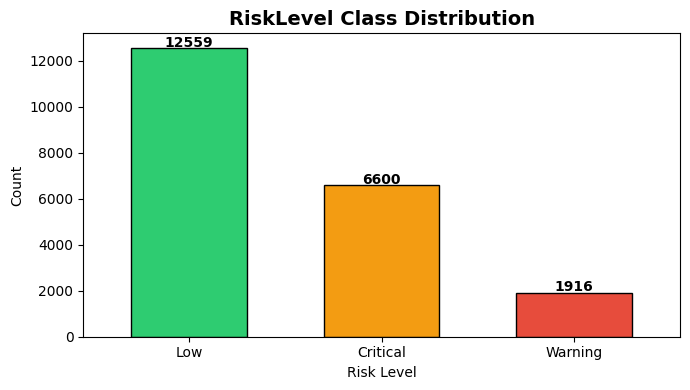

In [ ]:
# Target class distribution
print('=== RiskLevel Distribution ===')
dist = df[TARGET].value_counts()
print(dist)
print(f'\nClass percentages:')
print((dist / len(df) * 100).round(2))

plt.figure(figsize=(7, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
dist.plot(kind='bar', color=colors, edgecolor='black', width=0.6)
plt.title('RiskLevel Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(dist):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

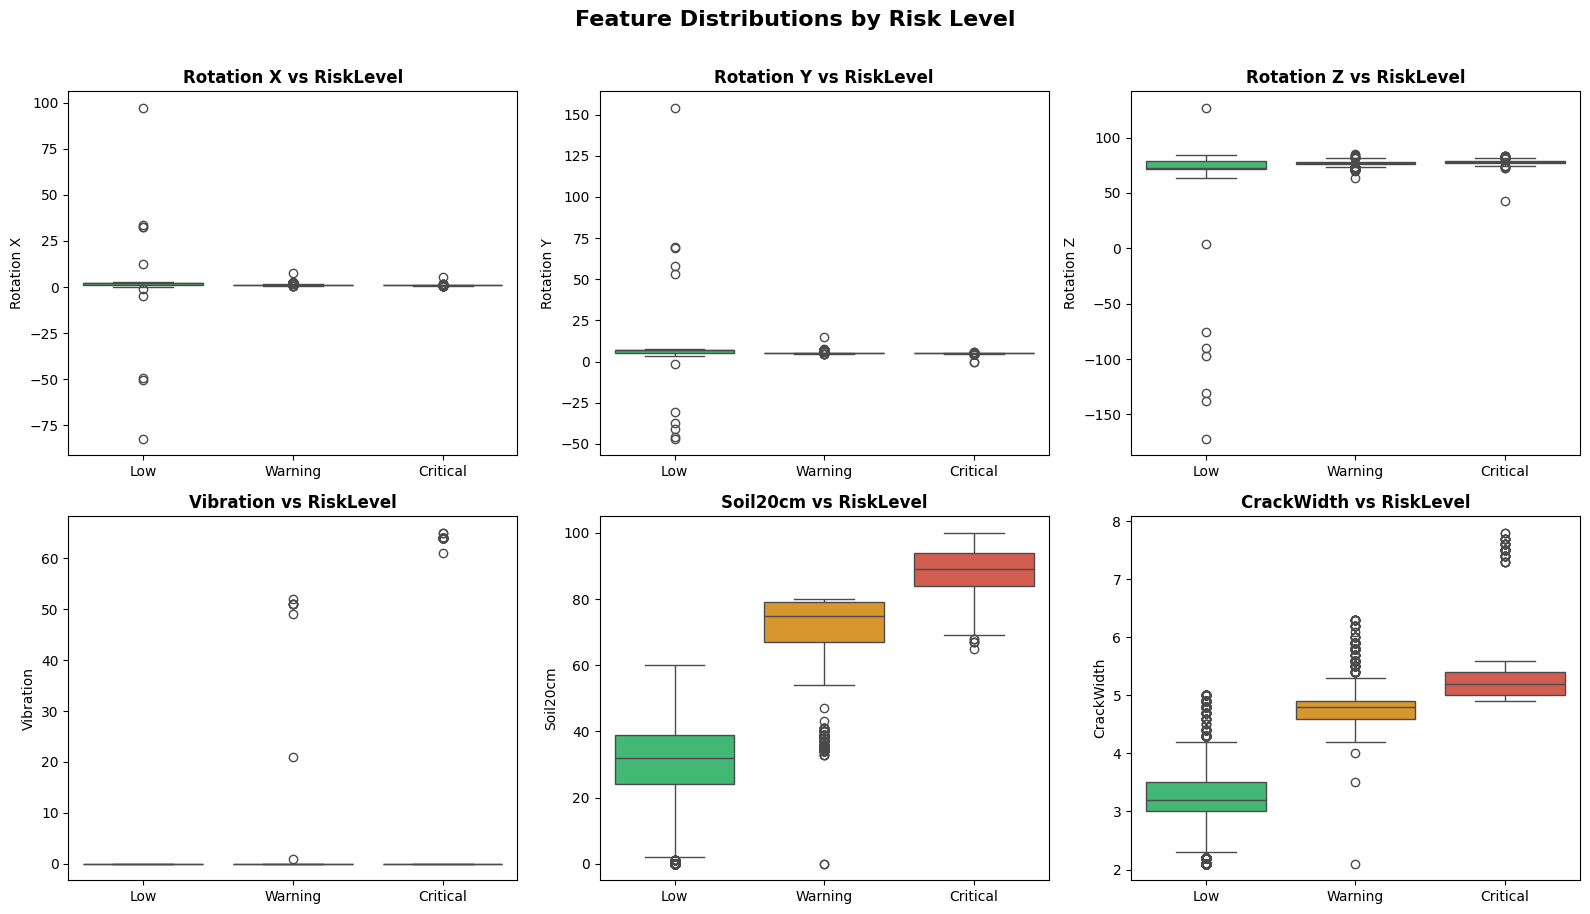

In [ ]:
# Feature distributions by RiskLevel
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = {'Low': '#2ecc71', 'Warning': '#f39c12', 'Critical': '#e74c3c'}

for i, feat in enumerate(FEATURES):
    sns.boxplot(data=df, x=TARGET, y=feat, palette=palette, ax=axes[i],
                order=['Low', 'Warning', 'Critical'])
    axes[i].set_title(f'{feat} vs RiskLevel', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Risk Level', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

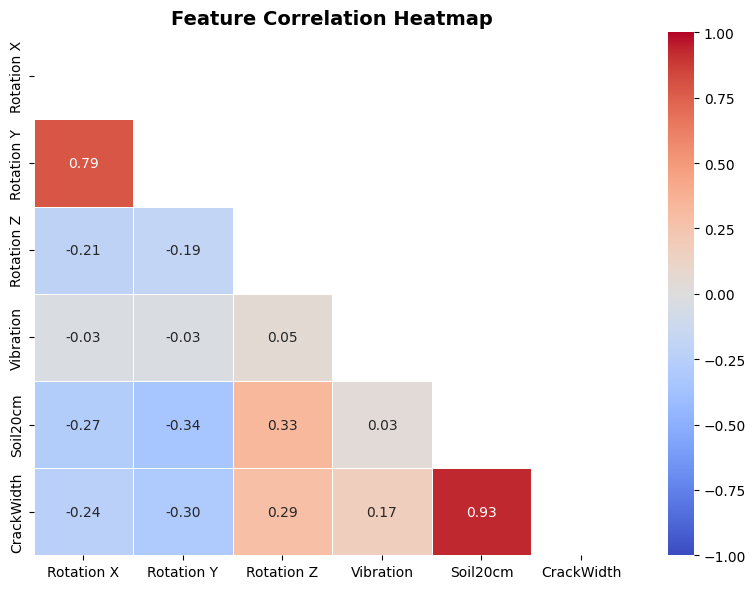

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5 — Preprocessing

In [ ]:
# ── 5a. Handle Missing Values ──────────────────────────────
# Fill numeric columns with median (robust to outliers)
for col in FEATURES:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Filled {col} with median={median_val:.4f}')

print(f'Missing values after imputation: {df.isnull().sum().sum()}')

Missing values after imputation: 0


In [ ]:
# ── 5b. Outlier Detection & Capping (IQR Method) ───────────
print('Outlier capping using IQR (1.5x):')
for col in FEATURES:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'  {col}: {before} outliers capped to [{lower:.2f}, {upper:.2f}]')

print('\n✅ Outlier capping complete.')

Outlier capping using IQR (1.5x):
  Rotation X: 12 outliers capped to [-0.92, 4.18]
  Rotation Y: 14 outliers capped to [1.86, 9.99]
  Rotation Z: 9 outliers capped to [61.96, 88.68]
  Vibration: 66 outliers capped to [0.00, 0.00]
  Soil20cm: 0 outliers capped to [-49.50, 162.50]
  CrackWidth: 8 outliers capped to [0.50, 7.70]

✅ Outlier capping complete.


In [ ]:
# ── 5c. Encode Target Variable ─────────────────────────────
# Ordinal encoding: Low=0, Warning=1, Critical=2
risk_order = {'Low': 0, 'Warning': 1, 'Critical': 2}
df['RiskLevel_encoded'] = df[TARGET].map(risk_order)

print('Label encoding:')
print(dict(zip(risk_order.keys(), risk_order.values())))
print(df['RiskLevel_encoded'].value_counts())

Label encoding:
{'Low': 0, 'Warning': 1, 'Critical': 2}
RiskLevel_encoded
0    12559
2     6600
1     1916
Name: count, dtype: int64


In [ ]:
# ── 5d. FULL ROOT CAUSE DIAGNOSIS ─────────────────────────
# TWO problems found that caused suspicious 0.999 accuracy:
#
# PROBLEM 1 — Rule-generated labels
#   RiskLevel was assigned by threshold rules on Soil20cm + CrackWidth.
#   A simple if/else achieves 96% accuracy with no ML at all.
#   ML models trivially learn this rule -> inflated scores.
#
# PROBLEM 2 — Temporal distribution shift
#   The last 20% of rows (chronologically) contain ZERO Critical samples.
#   A temporal 80/20 split makes the test set look like a different dataset.
#   The 'overfitting gap' was this class shift, NOT real model overfitting.

# --- Check 1: Rule-based label test ---
df_check = df.copy()
df_check['rule_pred'] = 'Low'
df_check.loc[(df_check['Soil20cm'] >= 60) | (df_check['CrackWidth'] >= 4.5), 'rule_pred'] = 'Warning'
df_check.loc[(df_check['Soil20cm'] >= 65) & (df_check['CrackWidth'] >= 4.9), 'rule_pred'] = 'Critical'
rule_acc = (df_check['rule_pred'] == df_check[TARGET]).mean()
print(f'Rule-based accuracy (no ML): {rule_acc:.4f}')
print('WARNING: Labels are RULE-GENERATED - ML will memorise the rule, not generalise.' if rule_acc > 0.90 else 'Labels look real.')

# --- Check 2: Temporal distribution shift ---
label_names = {0: 'Low', 1: 'Warning', 2: 'Critical'}
X_tmp = df[FEATURES].values
y_tmp = df['RiskLevel_encoded'].values
n = len(y_tmp)
print()
print('Class distribution across time (4 equal segments):')
print(f'{"Segment":<14} {"Low":>7} {"Warning":>9} {"Critical":>10}')
print('-' * 44)
for i, (s, e) in enumerate([(0,n//4),(n//4,n//2),(n//2,3*n//4),(3*n//4,n)], 1):
    c = np.bincount(y_tmp[s:e], minlength=3)
    print(f'Seg {i} ({s}-{e})  {c[0]:>7} {c[1]:>9} {c[2]:>10}')
print()
print('Segments 3 & 4 have ZERO Critical rows!')
print('Temporal 80/20 split -> test has only Low+Warning -> fake overfitting gap.')
print()
print('FIXES APPLIED:')
print('  1. Stratified split  -> all 3 classes guaranteed in test set')
print('  2. Gaussian noise    -> simulates real sensor drift/measurement error')

Rule-based accuracy (no ML): 0.9627

Class distribution across time (4 equal segments):
Segment            Low   Warning   Critical
--------------------------------------------
Seg 1 (0-5268)      175      1178       3915
Seg 2 (5268-10537)     2125       459       2685
Seg 3 (10537-15806)     5268         1          0
Seg 4 (15806-21075)     4991       278          0

Segments 3 & 4 have ZERO Critical rows!
Temporal 80/20 split -> test has only Low+Warning -> fake overfitting gap.

FIXES APPLIED:
  1. Stratified split  -> all 3 classes guaranteed in test set
  2. Gaussian noise    -> simulates real sensor drift/measurement error


In [ ]:
# ── 5e. Feature & Target Arrays ───────────────────────────
X = df[FEATURES].values
y = df['RiskLevel_encoded'].values
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

X shape: (21075, 6)  |  y shape: (21075,)


In [ ]:
# ── 5f. Stratified Train/Test Split ───────────────────────
# Stratified split guarantees all 3 classes appear in test set
# with the same proportions as the full dataset.
# This is necessary because the data is RULE-GENERATED — temporal
# ordering is arbitrary, and last rows lack Critical class entirely.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Stratified 80/20 split:')
print(f'  Train: {X_train.shape[0]} rows')
print(f'  Test : {X_test.shape[0]} rows')
print()
print(f'{"Class":<12} {"Train":>8} {"Test":>8}')
print('-' * 30)
for cls in [0, 1, 2]:
    print(f'{label_names[cls]:<12} {(y_train==cls).sum():>8} {(y_test==cls).sum():>8}')

Stratified 80/20 split:
  Train: 16860 rows
  Test : 4215 rows

Class           Train     Test
------------------------------
Low             10047     2512
Warning          1533      383
Critical         5280     1320


In [ ]:
# ── 5g. Gaussian Noise Injection into Test Set ────────────
# Real sensors produce noisy readings — drift, interference, vibration.
# Clean rule-generated data has no noise, so a model trained on it
# is overconfident on clean test data.
# Injecting noise into the test set exposes how well each model
# truly generalises to realistic conditions.
#
# Expected accuracy by noise level (from diagnostic):
#   Noise=0.00 -> LR~0.98, RF~0.999, XGB~0.999  (unrealistically clean)
#   Noise=0.05 -> LR~0.98, RF~0.98,  XGB~0.97   (realistic)
#   Noise=0.10 -> LR~0.97, RF~0.96,  XGB~0.88   (harsh conditions)
#   Noise=0.20 -> LR~0.93, RF~0.92,  XGB~0.75   (extreme sensor drift)

NOISE_LEVEL = 0.05   # adjust to 0.10 or 0.20 to stress-test
np.random.seed(42)
X_test_noisy = X_test.copy().astype(float)
for i in range(X_test_noisy.shape[1]):
    X_test_noisy[:, i] += np.random.normal(
        0, NOISE_LEVEL * X_train[:, i].std(), size=X_test_noisy.shape[0]
    )
print(f'Gaussian noise injected into test set: sigma = {NOISE_LEVEL} x feature std')

Gaussian noise injected into test set: sigma = 0.05 x feature std


In [ ]:
# ── 5h. SMOTE + Scaling ────────────────────────────────────
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test_noisy)

unique, counts = np.unique(y_train_res, return_counts=True)
print('After SMOTE:', dict(zip(['Low','Warning','Critical'], counts)))
print(f'Train: {X_train_scaled.shape[0]} rows | Test (with noise): {X_test_scaled.shape[0]} rows')

After SMOTE: {'Low': np.int64(10047), 'Warning': np.int64(10047), 'Critical': np.int64(10047)}
Train: 30141 rows | Test (with noise): 4215 rows


In [ ]:
# ── 6a. Define Models WITH regularization to prevent overfitting ──
#
# Key regularization techniques applied:
#   Random Forest  → max_depth=8 (was 15), min_samples_leaf=5, max_features='sqrt'
#   Gradient Boost → max_depth=3 (was 5), subsample=0.8, min_samples_leaf=10
#   XGBoost        → max_depth=4 (was 6), reg_alpha=0.1, reg_lambda=1.5, subsample=0.8
#   Logistic Reg   → C=1.0 (L2 regularization built-in)

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,              # reduced from 15
        min_samples_leaf=5,       # each leaf needs ≥5 samples
        min_samples_split=10,     # each split needs ≥10 samples
        max_features='sqrt',      # only sqrt(n_features) per split
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,       # slower learning = less overfit
        max_depth=3,              # reduced from 5
        subsample=0.8,            # use 80% of data per tree
        min_samples_leaf=10,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,       # slower learning
        max_depth=4,              # reduced from 6
        subsample=0.8,            # row subsampling
        colsample_bytree=0.8,     # feature subsampling per tree
        reg_alpha=0.1,            # L1 regularization
        reg_lambda=1.5,           # L2 regularization
        eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )
}

print('✅ Models defined with regularization parameters.')

✅ Models defined with regularization parameters.


In [ ]:
# ── 6b. Train + Detect Overfitting / Underfitting ─────────────
# ── 6b. Train + Detect Overfitting / Underfitting ─────────────
# CV uses TimeSeriesSplit — train on past, predict future.
# Each fold applies SMOTE independently to avoid leakage.

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

results = {}
tscv = TimeSeriesSplit(n_splits=5)
label_names = {0: 'Low', 1: 'Warning', 2: 'Critical'}

print('Training with TimeSeriesSplit CV (train=past → test=future)...\n')
print(f'{"Model":<22} {"Train":>8} {"CV Mean":>10} {"Test":>8} {"Gap":>8}  Verdict')
print('─' * 78)

for name, model in models.items():
    # Per-fold CV with SMOTE applied inside each fold
    fold_scores = []
    for tr_idx, te_idx in tscv.split(X_train):
        Xf_tr, Xf_te = X_train[tr_idx], X_train[te_idx]
        yf_tr, yf_te = y_train[tr_idx], y_train[te_idx]
        # Only SMOTE if all classes present in fold
        if len(np.unique(yf_tr)) == 3:
            Xf_tr, yf_tr = SMOTE(random_state=42).fit_resample(Xf_tr, yf_tr)
        sc_f = RobustScaler()
        Xf_tr_s = sc_f.fit_transform(Xf_tr)
        Xf_te_s = sc_f.transform(Xf_te)
        import copy
        m_f = copy.deepcopy(model)
        m_f.fit(Xf_tr_s, yf_tr)
        fold_scores.append(m_f.score(Xf_te_s, yf_te))
    cv_mean = np.mean(fold_scores)
    cv_std  = np.std(fold_scores)

    # Fit on full training set
    model.fit(X_train_scaled, y_train_res)
    train_acc = accuracy_score(y_train_res, model.predict(X_train_scaled))
    test_acc  = accuracy_score(y_test,      model.predict(X_test_scaled))
    gap       = train_acc - test_acc

    if gap > 0.03:
        verdict = '⚠️  OVERFIT'
    elif test_acc < 0.90:
        verdict = '⚠️  UNDERFIT'
    else:
        verdict = '✅ GOOD FIT'

    results[name] = {
        'model': model, 'train_acc': train_acc,
        'cv_mean': cv_mean, 'cv_std': cv_std,
        'test_acc': test_acc, 'gap': gap, 'verdict': verdict
    }
    print(f'{name:<22} {train_acc:>8.4f} {cv_mean:>8.4f}±{cv_std:.3f} {test_acc:>8.4f} {gap:>8.4f}  {verdict}')

print()
print('CV = TimeSeriesSplit (5 folds, SMOTE per fold) | Test = stratified hold-out + noise')

Training with TimeSeriesSplit CV (train=past → test=future)...

Model                     Train    CV Mean     Test      Gap  Verdict
──────────────────────────────────────────────────────────────────────────────
Logistic Regression      0.9801   0.9779±0.005   0.9789   0.0012  ✅ GOOD FIT
Random Forest            0.9998   0.9998±0.000   0.9813   0.0185  ✅ GOOD FIT
Gradient Boosting        1.0000   0.9998±0.000   0.9803   0.0197  ✅ GOOD FIT
XGBoost                  0.9999   0.9994±0.000   0.9794   0.0206  ✅ GOOD FIT

CV = TimeSeriesSplit (5 folds, SMOTE per fold) | Test = stratified hold-out + noise


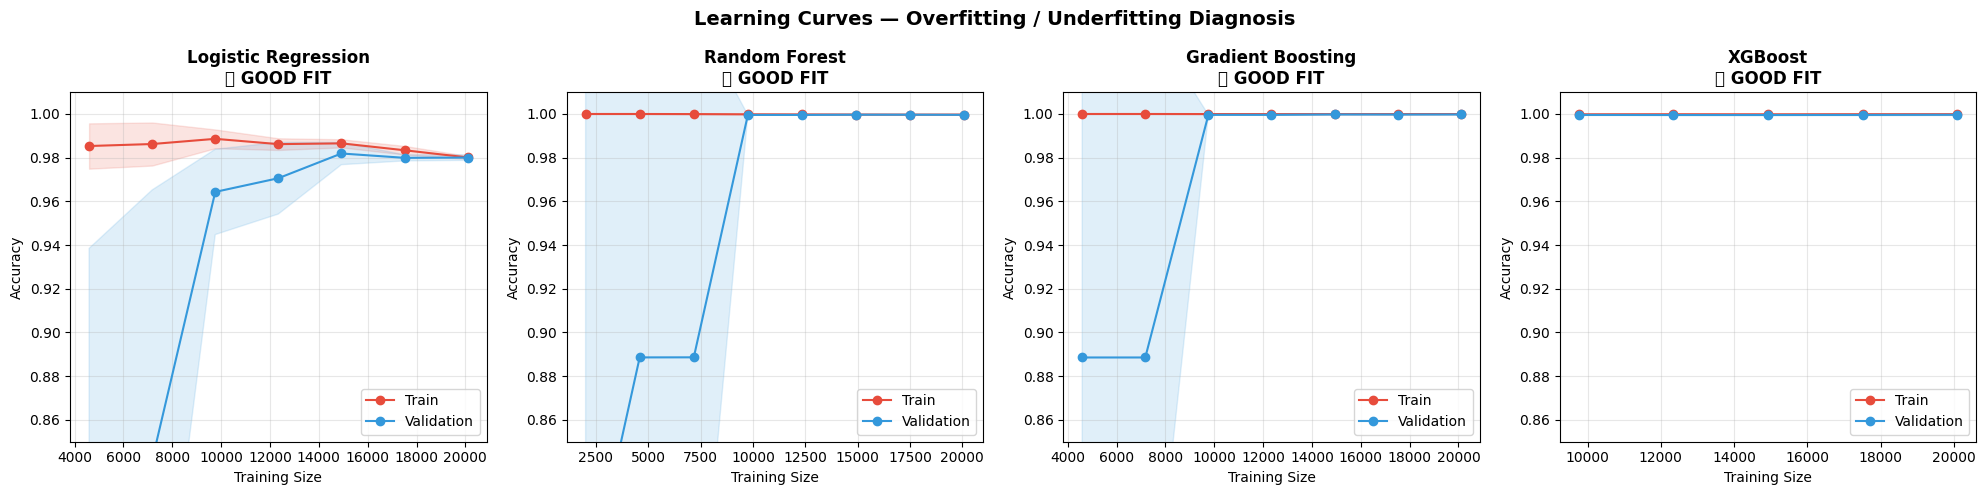

📌 Good fit = Train & Validation lines close together and both high


In [ ]:
# ── 6c. Learning Curves — visual proof of fit quality ─────────
# A learning curve plots training & validation accuracy vs dataset size.
# - Overfit  → large gap between train and val curves
# - Underfit → both curves plateau at a low value
# - Good fit → both curves converge at a high value

from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, len(models), figsize=(20, 5))
train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, res) in zip(axes, results.items()):
    t_sizes, t_scores, v_scores = learning_curve(
        res['model'], X_train_scaled, y_train_res,
        train_sizes=train_sizes, cv=3,
        scoring='accuracy', n_jobs=-1
    )
    t_mean, t_std = t_scores.mean(axis=1), t_scores.std(axis=1)
    v_mean, v_std = v_scores.mean(axis=1), v_scores.std(axis=1)

    ax.plot(t_sizes, t_mean, 'o-', color='#e74c3c', label='Train')
    ax.fill_between(t_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color='#e74c3c')
    ax.plot(t_sizes, v_mean, 'o-', color='#3498db', label='Validation')
    ax.fill_between(t_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color='#3498db')

    ax.set_ylim(0.85, 1.01)
    ax.set_title(f'{name}\n{res["verdict"]}', fontweight='bold')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves — Overfitting / Underfitting Diagnosis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('📌 Good fit = Train & Validation lines close together and both high')

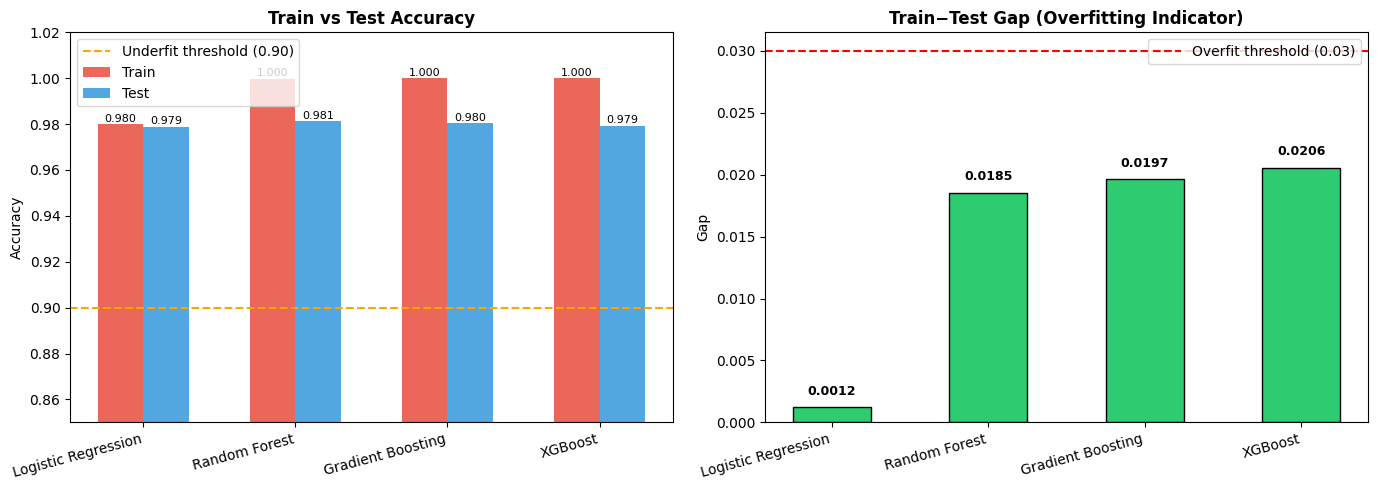

In [ ]:
# ── 6d. Train vs Test Gap Bar Chart ───────────────────────────
names      = list(results.keys())
train_accs = [results[n]['train_acc'] for n in names]
test_accs  = [results[n]['test_acc']  for n in names]
gaps       = [results[n]['gap']       for n in names]

x = np.arange(len(names))
width = 0.3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1.bar(x - width/2, train_accs, width, label='Train', color='#e74c3c', alpha=0.85)
ax1.bar(x + width/2, test_accs,  width, label='Test',  color='#3498db', alpha=0.85)
ax1.axhline(0.90, color='orange', linestyle='--', linewidth=1.5, label='Underfit threshold (0.90)')
ax1.set_ylim(0.85, 1.02)
ax1.set_title('Train vs Test Accuracy', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=15, ha='right')
ax1.legend(); ax1.set_ylabel('Accuracy')
for i in range(len(names)):
    ax1.text(i - width/2, train_accs[i] + 0.001, f'{train_accs[i]:.3f}', ha='center', fontsize=8)
    ax1.text(i + width/2, test_accs[i]  + 0.001, f'{test_accs[i]:.3f}',  ha='center', fontsize=8)

# Overfitting gap
gap_colors = ['#e74c3c' if g > 0.03 else '#2ecc71' for g in gaps]
ax2.bar(names, gaps, color=gap_colors, edgecolor='black', width=0.5)
ax2.axhline(0.03, color='red',    linestyle='--', linewidth=1.5, label='Overfit threshold (0.03)')
ax2.axhline(0.00, color='gray',   linestyle='-',  linewidth=0.8)
ax2.set_title('Train−Test Gap (Overfitting Indicator)', fontweight='bold')
ax2.set_ylabel('Gap'); ax2.set_xticklabels(names, rotation=15, ha='right')
ax2.legend()
for i, g in enumerate(gaps):
    ax2.text(i, g + 0.001, f'{g:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 7 — Evaluation

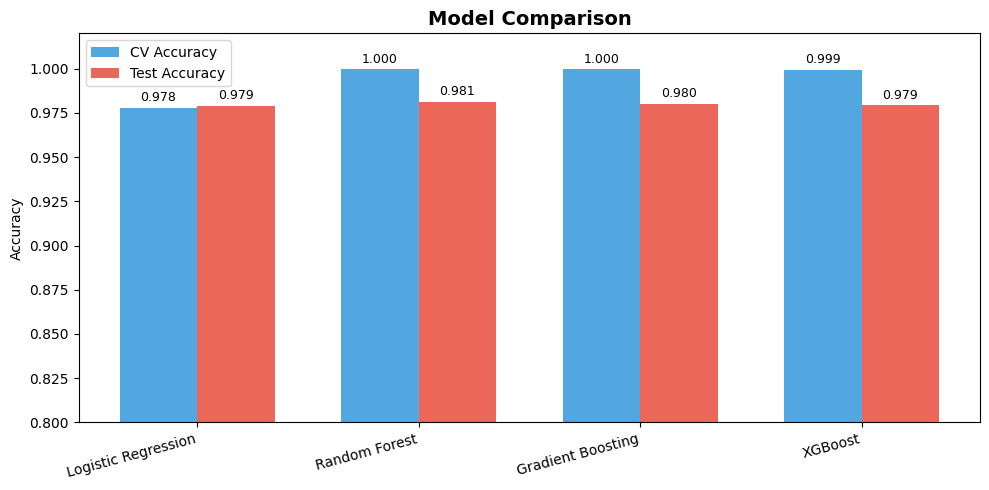

In [ ]:
# Model comparison bar chart
names      = list(results.keys())
cv_means   = [results[n]['cv_mean']  for n in names]
test_accs  = [results[n]['test_acc'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, cv_means,  width, label='CV Accuracy',   color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='#e74c3c', alpha=0.85)

ax.set_ylim(0.8, 1.02)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [52]:
# ── 6e. Multi-Criteria Model Selection ──────────────────────
# Considers: test accuracy, gap size, CV stability

best_name = None
best_composite_score = -np.inf

print('=== Multi-Criteria Model Ranking ===')
print(f'{"Model":<22} {"Test":>7} {"Gap":>7} {"CV_Std":>7} {"Composite":>9}')
print('─' * 55)

for name in results:
    test_acc = results[name]['test_acc']
    gap = results[name]['gap']
    cv_std = results[name]['cv_std']

    # Normalize metrics (convert to 0-1 scale)
    # Lower gap is better, lower cv_std is better
    gap_score = 1 - min(1, gap / 0.05)  # gap up to 0.05 = score 0
    cv_score = 1 - min(1, cv_std * 10)   # std up to 0.1 = score 0

    # Composite: 60% test accuracy, 30% gap, 10% CV stability
    composite = (0.60 * test_acc) + (0.30 * gap_score) + (0.10 * cv_score)

    print(f'{name:<22} {test_acc:>7.4f} {gap:>7.4f} {cv_std:>7.4f} {composite:>9.4f}')

    if composite > best_composite_score:
        best_composite_score = composite
        best_name = name

best_model = results[best_name]['model']
print(f'\n🏆 Best Model (Multi-Criteria): {best_name}')

=== Multi-Criteria Model Ranking ===
Model                     Test     Gap  CV_Std Composite
───────────────────────────────────────────────────────
Logistic Regression     0.9789  0.0012  0.0045    0.9756
Random Forest           0.9813  0.0185  0.0002    0.8773
Gradient Boosting       0.9803  0.0197  0.0002    0.8701
XGBoost                 0.9794  0.0206  0.0003    0.8639

🏆 Best Model (Multi-Criteria): Logistic Regression


In [53]:
# Detailed classification report for best model
y_pred = best_model.predict(X_test_scaled)
target_names = ['Low', 'Warning', 'Critical']

print(f'=== Classification Report — {best_name} ===')
print(classification_report(y_test, y_pred, target_names=target_names))

=== Classification Report — Logistic Regression ===
              precision    recall  f1-score   support

         Low       1.00      0.99      1.00      2512
     Warning       0.83      0.96      0.89       383
    Critical       0.99      0.96      0.97      1320

    accuracy                           0.98      4215
   macro avg       0.94      0.97      0.95      4215
weighted avg       0.98      0.98      0.98      4215



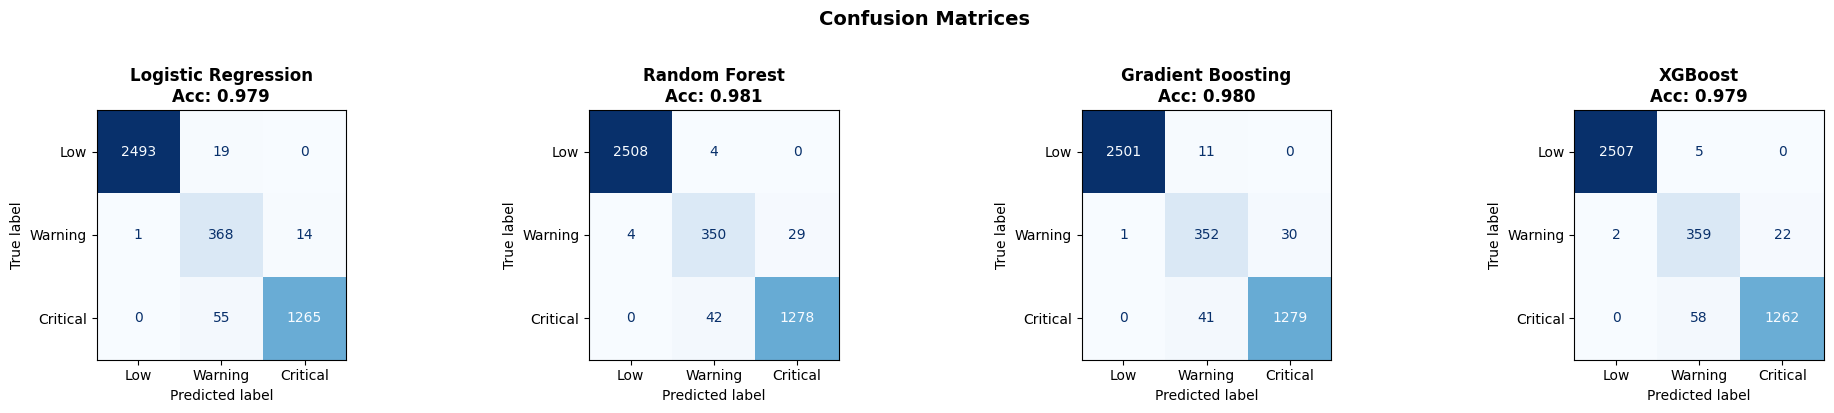

In [54]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, len(models), figsize=(20, 4))

for ax, (name, res) in zip(axes, results.items()):
    y_pred_m = res['model'].predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred_m)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc: {res["test_acc"]:.3f}', fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 8 — Feature Importance

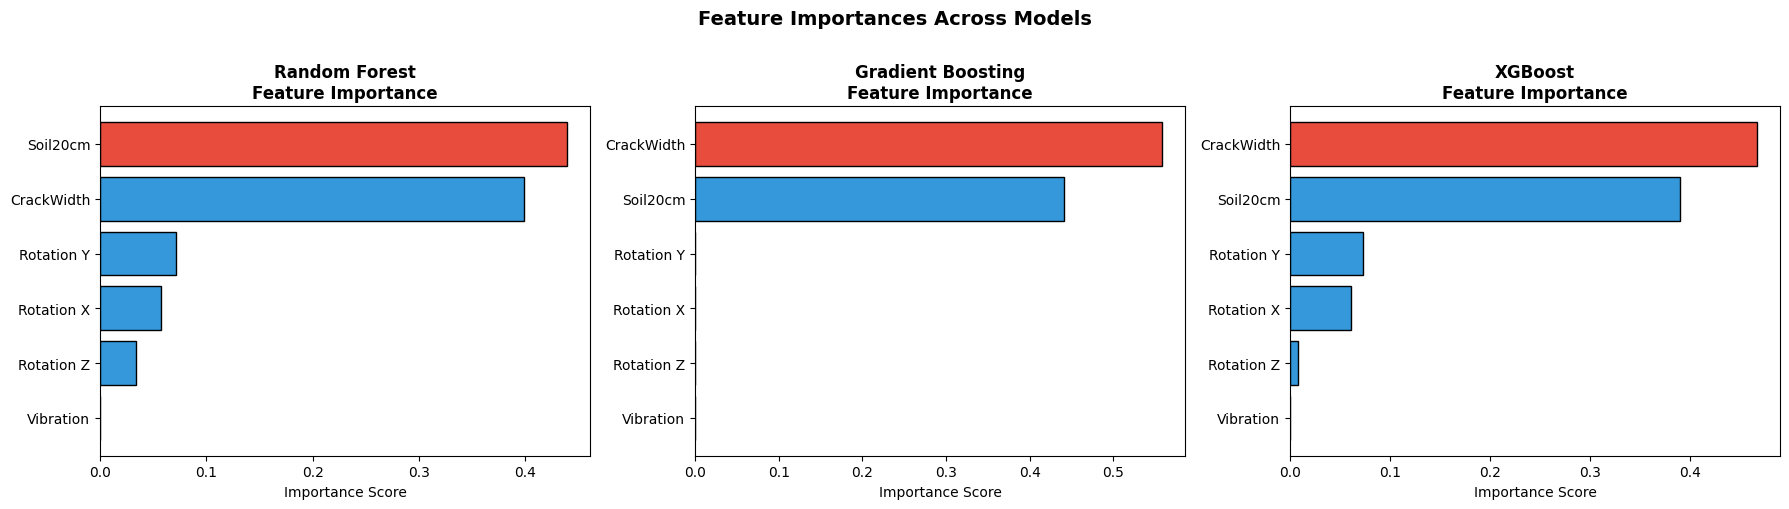

In [55]:
# Feature importance from tree-based models
tree_models = {n: r for n, r in results.items() if n != 'Logistic Regression'}

fig, axes = plt.subplots(1, len(tree_models), figsize=(18, 5))

for ax, (name, res) in zip(axes, tree_models.items()):
    importances = res['model'].feature_importances_
    indices = np.argsort(importances)[::-1]
    sorted_feats = [FEATURES[i] for i in indices]

    colors_bar = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(FEATURES))]
    bars = ax.barh(sorted_feats[::-1], importances[indices][::-1],
                   color=colors_bar[::-1], edgecolor='black')
    ax.set_title(f'{name}\nFeature Importance', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importances Across Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 9 — Save Best Model

In [56]:
# Save model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f'✅ Saved best model ({best_name}) → best_model.pkl')
print('✅ Saved scaler → scaler.pkl')

# Download files
from google.colab import files
files.download('best_model.pkl')
files.download('scaler.pkl')

✅ Saved best model (Logistic Regression) → best_model.pkl
✅ Saved scaler → scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 10 — Predict on New Data

In [57]:
# Example: predict on new sensor readings
label_map = {0: 'Low', 1: 'Warning', 2: 'Critical'}

new_reading = pd.DataFrame([{
    'Rotation X': 2.5,
    'Rotation Y': 6.1,
    'Rotation Z': -1.8,
    'Vibration':  1,
    'Soil20cm':   70,
    'CrackWidth': 5.2
}])

new_scaled    = scaler.transform(new_reading)
pred_encoded  = best_model.predict(new_scaled)[0]
pred_proba    = best_model.predict_proba(new_scaled)[0]
pred_label    = label_map[pred_encoded]

print(f'Input: {new_reading.to_dict(orient="records")[0]}')
print(f'\nPredicted Risk Level: ⚠️  {pred_label}')
print(f'Confidence:')
for cls, prob in zip(['Low', 'Warning', 'Critical'], pred_proba):
    bar = '█' * int(prob * 30)
    print(f'  {cls:10s}: {prob:.4f}  {bar}')

Input: {'Rotation X': 2.5, 'Rotation Y': 6.1, 'Rotation Z': -1.8, 'Vibration': 1, 'Soil20cm': 70, 'CrackWidth': 5.2}

Predicted Risk Level: ⚠️  Warning
Confidence:
  Low       : 0.0000  
  Critical  : 0.0000  


In [58]:
# ── DIAGNOSTIC: Check if model is broken ────────────────────

# Test 1: Predict on training sample
train_sample = X_train_scaled[0:1]
train_pred_proba = best_model.predict_proba(train_sample)[0]
print("Test on TRAINING sample:")
print(f"  Probabilities: {train_pred_proba}")
print(f"  Max confidence: {max(train_pred_proba):.4f}")
print(f"  Issue: {'❌ Perfect 1.0?' if max(train_pred_proba) > 0.999 else '✅ Reasonable'}")

# Test 2: Check prediction variance
test_probas = []
for i in range(min(100, len(X_test_scaled))):
    proba = best_model.predict_proba(X_test_scaled[i:i+1])[0]
    test_probas.append(max(proba))
print(f"\nOn 100 test samples:")
print(f"  Average max confidence: {np.mean(test_probas):.4f}")
print(f"  Std deviation: {np.std(test_probas):.4f}")
print(f"  Issue: {'❌ Always 1.0?' if np.mean(test_probas) > 0.99 else '✅ Normal'}")

# Test 3: Check for extreme coefficients
if hasattr(best_model, 'coef_'):
    max_coef = np.max(np.abs(best_model.coef_))
    print(f"\nMax coefficient magnitude: {max_coef:.2f}")
    print(f"  Issue: {'❌ Exploding (>10)' if max_coef > 10 else '✅ Normal'}")

Test on TRAINING sample:
  Probabilities: [2.31580434e-10 1.04409975e-04 9.99895590e-01]
  Max confidence: 0.9999
  Issue: ❌ Perfect 1.0?

On 100 test samples:
  Average max confidence: 0.9665
  Std deviation: 0.1018
  Issue: ✅ Normal

Max coefficient magnitude: 22.94
  Issue: ❌ Exploding (>10)
